# INITIALIZATION

In [ ]:
import os
import mne
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from config import HGD_DATA_PATH
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mne.set_log_level('WARNING') 


LOW_FREQ = 8.
HIGH_FREQ = 30.
SAMPLING_RATE = 250

In [ ]:
from braindecode.datasets.bbci import  BBCIDataset
cnt = BBCIDataset(filename='./test/1.mat', load_sensor_names=None).load()

<Info | 10 non-empty values
 bads: []
 ch_names: C3, C4, Cz
 chs: 3 EEG
 custom_ref_applied: False
 dig: 19 items (3 Cardinal, 16 EEG)
 file_id: 4 items (dict)
 highpass: 8.0 Hz
 lowpass: 30.0 Hz
 meas_date: 1970-01-01 00:00:00 UTC
 meas_id: 4 items (dict)
 nchan: 3
 projs: []
 sfreq: 250.0 Hz
>


In [4]:
def load_data(path, channels = ['C3', 'C4', 'Cz'], format = '.gdf', sampling_rate = SAMPLING_RATE, low_freq = LOW_FREQ, high_freq = HIGH_FREQ):
    parent_dir = os.path.dirname(path)
    raw_files = [os.path.join(parent_dir, f) for f in os.listdir(parent_dir) if f.endswith(format)]
    print(f"Found {len(raw_files)} raw data files in {path}.")
    raw_data = []
    for file in raw_files:
        raw = mne.io.read_raw_fif(file, preload=True)

        if raw.info['sfreq'] != sampling_rate:
            raw.resample(sampling_rate)

        raw.set_montage('standard_1020')

        if channels is not None:
            raw.pick_channels(channels)

        raw.notch_filter(50)

        raw_data.append(raw)
    return raw_data    

In [5]:
channels = ['C3','C4','Cz','T7','T8','F3','F4','P3','P4', 'Stim']

In [6]:
dataset = load_data(
    path = MI_DATA_PATH,
    channels = channels,
    format = '.fif',
    low_freq=LOW_FREQ, 
    high_freq=HIGH_FREQ)
print(f"Loaded Training BCI2A data: {len(dataset)} files")

Found 7 raw data files in ./data/MI2Class/.
Loaded Training BCI2A data: 7 files


# PREPROCESSING 

In [7]:
event_id = {'left': 2, 'right': 3}
bands = [(8, 12), (13, 30)]

In [8]:
from mne.preprocessing import ICA

def run_ica(raw, n_components=20):
    ica = ICA(n_components=n_components, random_state=42, max_iter="auto")
    ica.fit(raw, verbose=False)

    eog_indices, _ = ica.find_bads_eog(raw)
    ica.exclude = eog_indices

    raw_clean = raw.copy()
    ica.apply(raw_clean)
    return raw_clean

def create_epochs(raw, event_id):
    events = mne.find_events(raw)
    epochs = mne.Epochs(
        raw,
        events,
        event_id=event_id,
        tmin=0.5,
        tmax=4.5,
        baseline=None,
        preload=True
    )
    return epochs

bands = [(8,12), (12,20), (20,30)]
def multi_band_filter(raw, bands):
    band_data = []
    for l, h in bands:
        filtered = raw.copy().filter(l, h, verbose=False)
        band_data.append(filtered.get_data())  # (C, T)
    
    return np.concatenate(band_data, axis=1)  # (C * num_bands, T)


def preprocess_raw(raw, event_id, bands=None):
    # raw_clean = run_ica(raw, n_components=6)
    epochs = create_epochs(raw, event_id)
    X, y = epochs.get_data(), epochs.events[:, -1]
    # X, y = multi_band_filter(epochs, bands), epochs.events[:, -1]
    return X, y


In [9]:
from sklearn.model_selection import train_test_split
X_all, y_all = [], []

for raw in dataset:
    X_raw, y_raw = preprocess_raw(raw, event_id)
    X_all.append(X_raw)
    y_raw = np.where(y_raw == 2, 0, 1)  
    y_all.append(y_raw)


X = np.concatenate(X_all)
y = np.concatenate(y_all)

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [10]:
mean = X_train.mean(axis=(0,2), keepdims=True)
std  = X_train.std(axis=(0,2), keepdims=True)

X_train = (X_train - mean) / std
X_val   = (X_val - mean) / std

In [11]:
X_train.shape, y_train.shape

((220, 10, 1001), (220,))

In [12]:
# Checking Balance in Training Data
unique, counts = np.unique(y_train, return_counts=True)
print("Class Distribution in Training Data:")
for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count} samples")


Class Distribution in Training Data:
Class 0: 112 samples
Class 1: 108 samples


In [13]:
X_train = np.transpose(X_train, (0, 2, 1))  # (N, T, C)
X_val   = np.transpose(X_val, (0, 2, 1))

In [14]:
X_train.shape, y_train.shape

((220, 1001, 10), (220,))

## MODEL

In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math


# ---------------------------
# Positional Encoding
# ---------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=2000):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(
            torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model)
        )

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

class AttentionPooling(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.attn = nn.Linear(dim, 1)

    def forward(self, x):
        weights = torch.softmax(self.attn(x), dim=1)
        return (x * weights).sum(dim=1)


# ---------------------------
# Multi-scale Residual Block
# ---------------------------
class MultiScaleBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.branch3 = nn.Conv1d(in_ch, out_ch, 3, padding=1)
        self.branch5 = nn.Conv1d(in_ch, out_ch, 5, padding=2)
        self.branch7 = nn.Conv1d(in_ch, out_ch, 7, padding=3)

        self.bn = nn.BatchNorm1d(out_ch)
        self.dropout = nn.Dropout(0.2)

        self.residual = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x):
        out = self.branch3(x) + self.branch5(x) + self.branch7(x)
        out = self.bn(out)
        out = self.dropout(out)

        return F.elu(self.residual(x) + 0.3 * out)

class SpatialBlock(nn.Module):
    def __init__(self, in_channels, n_channels):
        super().__init__()

        self.depthwise = nn.Conv1d(
            in_channels,
            in_channels,
            kernel_size=1,
            groups=in_channels  # channel-wise
        )

        self.pointwise = nn.Conv1d(in_channels, 64, kernel_size=1)

        self.bn = nn.BatchNorm1d(64)

    def forward(self, x):
        x = self.depthwise(x)
        x = self.pointwise(x)
        return F.elu(self.bn(x))

class FilterBank(nn.Module):
    def __init__(self, in_channels, out_channels=32):
        super().__init__()

        self.conv = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size=25,   # ~100 ms window
            padding=12,
            bias=False
        )

        self.bn = nn.BatchNorm1d(out_channels)

    def forward(self, x):
        return F.elu(self.bn(self.conv(x)))

# ---------------------------
# EEG Model
# ---------------------------
class EEGModel(nn.Module):
    def __init__(self, n_channels, n_classes, max_len=1000):
        super().__init__()

        # 1. Filterbank (frequency learning)
        self.filterbank = FilterBank(n_channels, 32)

        # 2. Spatial learning
        self.spatial = SpatialBlock(32, n_channels)

        # 3. CNN feature extractor
        self.cnn = nn.Sequential(
            MultiScaleBlock(64, 128),
            nn.MaxPool1d(2),

            MultiScaleBlock(128, 128),
            nn.MaxPool1d(2),
        )

        # 4. Learnable positional encoding
        self.pos_embedding = nn.Parameter(torch.randn(1, max_len, 128))

        # 5. Transformer
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=128,
            nhead=4,
            dim_feedforward=256,
            dropout=0.1,
            batch_first=True
        )

        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

        # 6. Attention pooling
        self.attn_pool = AttentionPooling(128)

        # 7. Classifier
        self.fc = nn.Sequential(
            nn.Linear(128, 128),
            nn.LayerNorm(128),
            nn.ELU(),
            nn.Dropout(0.5),
            nn.Linear(128, n_classes)
        )

    def forward(self, x):
        # (N, T, C) → (N, C, T)
        x = x.permute(0, 2, 1)

        # Filterbank
        x = self.filterbank(x)        # (N, 32, T)

        # Spatial
        x = self.spatial(x)           # (N, 64, T)

        # CNN
        x = self.cnn(x)               # (N, 128, T')

        # (N, C, T) → (N, T, C)
        x = x.permute(0, 2, 1)

        # Positional embedding
        x = x + self.pos_embedding[:, :x.size(1)]

        # Transformer
        x = self.transformer(x)

        # Attention pooling
        x = self.attn_pool(x)

        return self.fc(x)

In [16]:
model = EEGModel(n_channels=X_train.shape[2], n_classes=2)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=120)

In [17]:
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

def evaluate(model, loader, criterion, device="cpu"):
    model.eval()
    preds, labels = [], []
    total_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            total_loss += loss.item()

            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(loader)
    acc = accuracy_score(labels, preds)

    return avg_loss, acc

In [18]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

In [19]:
from torch.utils.data import DataLoader, TensorDataset
BATCH_SIZE = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [20]:
from tqdm import tqdm
import torch

def augment(x):
    # x: (B, T, C)

    # Gaussian noise
    x = x + 0.01 * torch.randn_like(x)

    # Time shift
    shift = np.random.randint(-20, 20)
    x = torch.roll(x, shifts=shift, dims=1)

    # Channel dropout
    if np.random.rand() < 0.3:
        mask = torch.rand(x.shape[2], device=x.device) > 0.1
        x = x * mask

    return x

def train(model, train_loader, val_loader, optimizer, criterion, scheduler=None, epochs=20, device="cpu"):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)



    for epoch in range(epochs):
        model.train()
        total_loss = 0

        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]", leave=False)

        for X_batch, y_batch in loop:
            X_batch = augment(X_batch)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            loop.set_postfix(loss=loss.item())

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss) 
            else:
                scheduler.step()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

    return history

In [21]:
def final_evaluation(model, loader, device="cpu"):
    model = model.to(device)
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    print("Final Accuracy:", accuracy_score(labels, preds))
    print(classification_report(labels, preds))

In [22]:
import matplotlib.pyplot as plt

def plot_history(history):
    plt.figure()
    plt.plot(history["train_loss"], label="Train Loss")
    plt.plot(history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title("Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

    plt.figure()
    plt.plot(history["val_acc"], label="Val Accuracy")
    plt.legend()
    plt.title("Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.show()


Epoch 1/80
Train Loss: 0.6671
Val Loss: 0.6232 | Val Acc: 1.0000



Epoch 2/80
Train Loss: 0.4547
Val Loss: 0.4335 | Val Acc: 1.0000



Epoch 3/80
Train Loss: 0.2962
Val Loss: 0.2394 | Val Acc: 1.0000



Epoch 4/80
Train Loss: 0.2205
Val Loss: 0.1999 | Val Acc: 1.0000



Epoch 5/80
Train Loss: 0.2157
Val Loss: 0.2072 | Val Acc: 1.0000


...


Epoch 76/80
Train Loss: 0.2059
Val Loss: 0.1989 | Val Acc: 1.0000



Epoch 77/80
Train Loss: 0.2742
Val Loss: 0.1991 | Val Acc: 1.0000



Epoch 78/80
Train Loss: 0.2722
Val Loss: 0.1994 | Val Acc: 1.0000



Epoch 79/80
Train Loss: 0.2064
Val Loss: 0.1991 | Val Acc: 1.0000



Epoch 80/80
Train Loss: 0.2790
Val Loss: 0.1991 | Val Acc: 1.0000


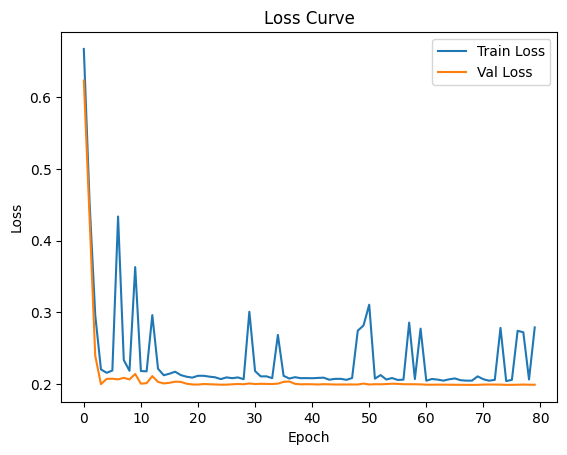

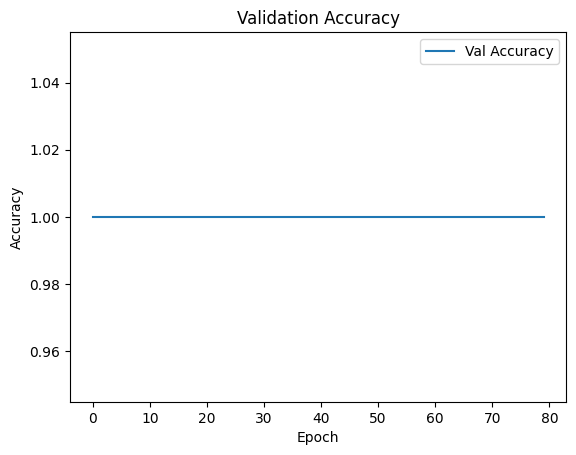

Final Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        28
           1       1.00      1.00      1.00        27

    accuracy                           1.00        55
   macro avg       1.00      1.00      1.00        55
weighted avg       1.00      1.00      1.00        55



In [23]:
history = train(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    scheduler=scheduler,
    epochs=80,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

plot_history(history)
final_evaluation(model, val_loader)

In [30]:
torch.save(model.state_dict(), "./output/eeg_model_improved.pth")

# TRAINING PER SUBJECT 

In [24]:
import torch
import torch.nn as nn
import numpy as np
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
BATCH_SIZE = 16
EPOCHS = 20

In [25]:
def final_evaluation(model, loader, device="cpu"):
    model = model.to(device)
    model.eval()
    preds, labels = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device)

            outputs = model(X_batch)
            predicted = torch.argmax(outputs, dim=1)

            preds.extend(predicted.cpu().numpy())
            labels.extend(y_batch.cpu().numpy())

    acc = np.mean(np.array(preds) == np.array(labels))
    return acc, preds, labels

In [26]:
from tqdm import tqdm
import torch

def augment(x):
    # x: (B, T, C)
    
    # Gaussian noise
    x = x + 0.01 * torch.randn_like(x)
    
    # Time shift
    shift = torch.randint(-20, 20, (1,)).item()
    x = torch.roll(x, shifts=shift, dims=1)
    
    return x

def train(model, train_loader, val_loader, optimizer, criterion, scheduler=None, epochs=20, device="cpu"):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    model.to(device)

    # total steps for tqdm = epochs * len(train_loader)
    pbar = tqdm(total=epochs * len(train_loader), desc="Training", leave=True)

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = augment(X_batch)
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # update same progress bar
            pbar.update(1)
            pbar.set_postfix({
                "epoch": epoch + 1,
                "loss": f"{loss.item():.4f}"
            })

        avg_train_loss = total_loss / len(train_loader)

        # Validation
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(val_loss)
            else:
                scheduler.step()

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        # update tqdm postfix with validation info
        pbar.set_postfix({
            "epoch": epoch + 1,
            "train_loss": f"{avg_train_loss:.4f}",
            "val_acc": f"{val_acc:.4f}"
        })

    pbar.close()
    return history

===== Processing Subject 1/7 =====


Training:   0%|          | 0/40 [00:00<?, ?it/s]

Training: 100%|██████████| 40/40 [00:01<00:00, 24.94it/s, epoch=20, train_loss=0.2256, val_acc=1.0000]


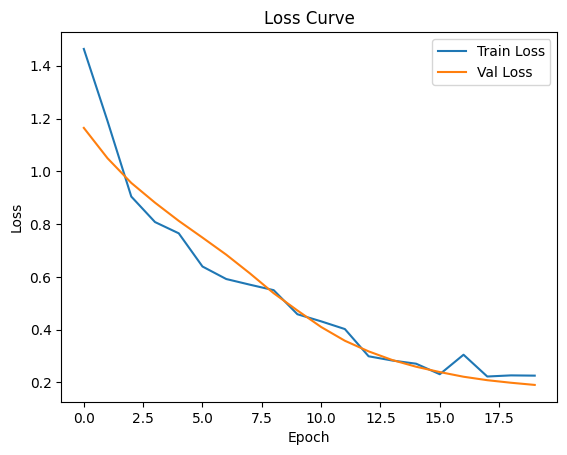

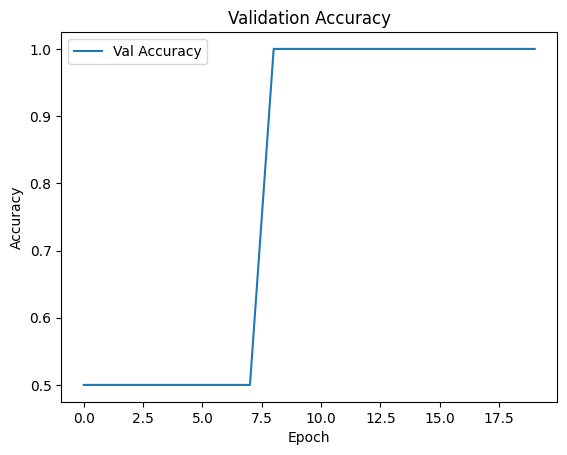

===== Processing Subject 2/7 =====


Training: 100%|██████████| 40/40 [00:01<00:00, 29.64it/s, epoch=20, train_loss=0.0769, val_acc=1.0000]


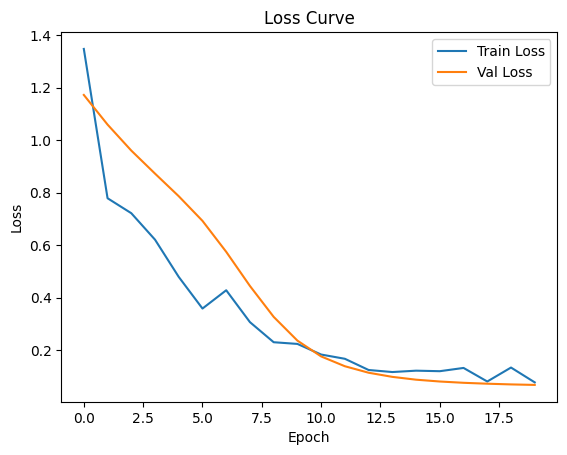

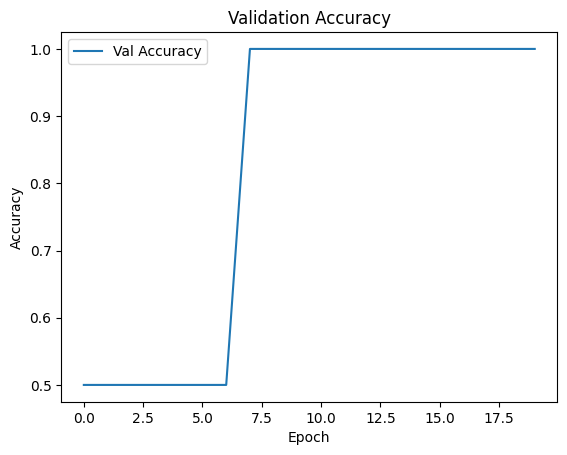

===== Processing Subject 3/7 =====


Training: 100%|██████████| 40/40 [00:01<00:00, 32.24it/s, epoch=20, train_loss=0.1558, val_acc=1.0000]


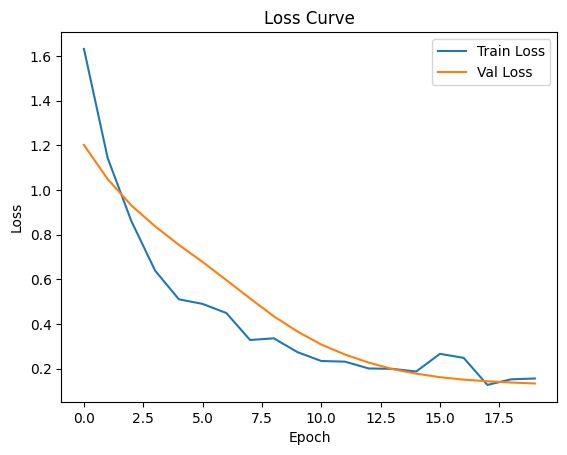

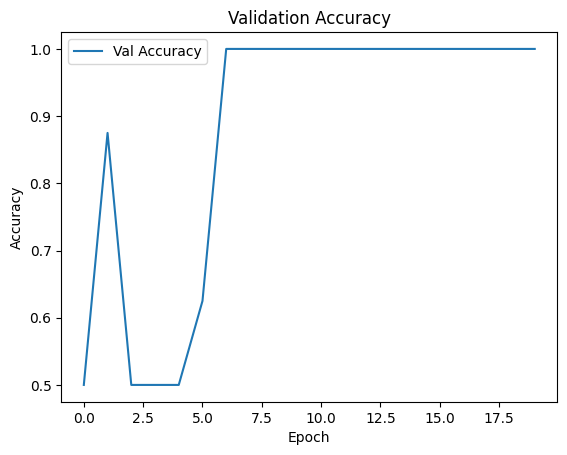

===== Processing Subject 4/7 =====


Training: 100%|██████████| 40/40 [00:01<00:00, 28.94it/s, epoch=20, train_loss=0.2234, val_acc=1.0000]


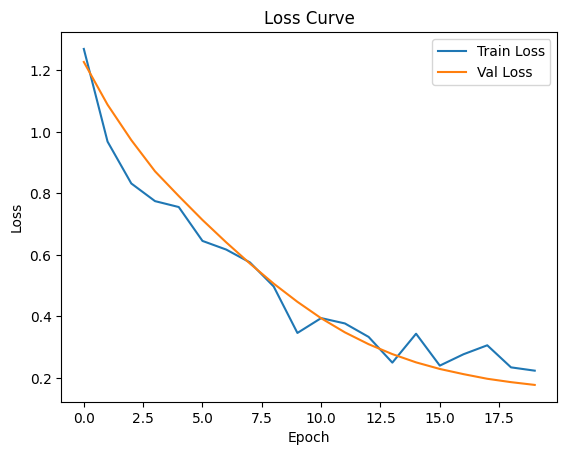

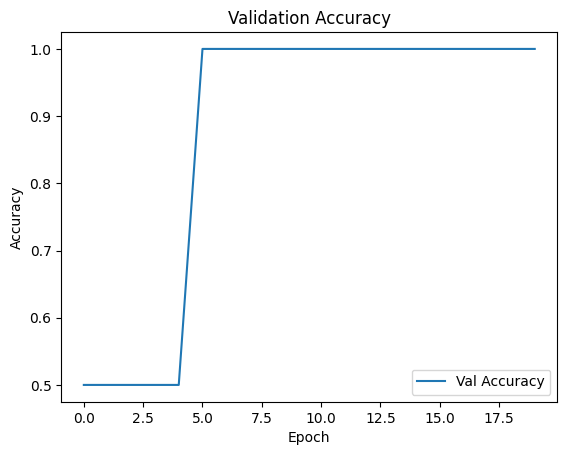

===== Processing Subject 5/7 =====


Training: 100%|██████████| 40/40 [00:01<00:00, 28.67it/s, epoch=20, train_loss=0.1135, val_acc=1.0000]


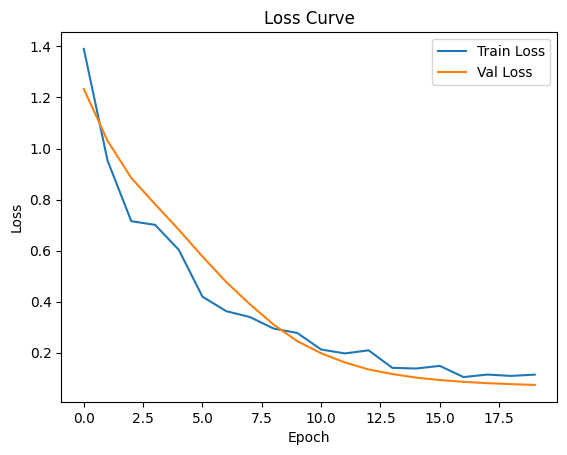

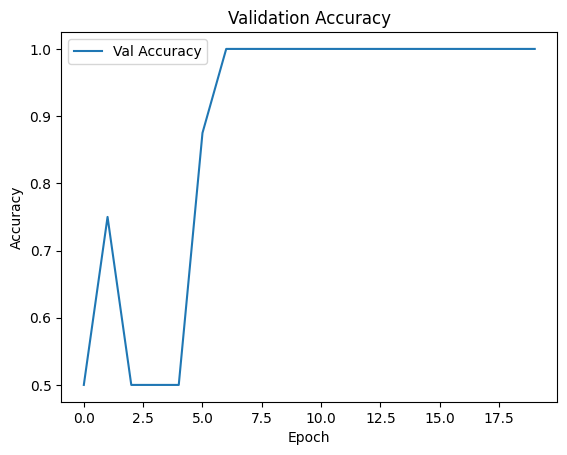

===== Processing Subject 6/7 =====


Training: 100%|██████████| 40/40 [00:01<00:00, 28.00it/s, epoch=20, train_loss=0.1391, val_acc=1.0000]


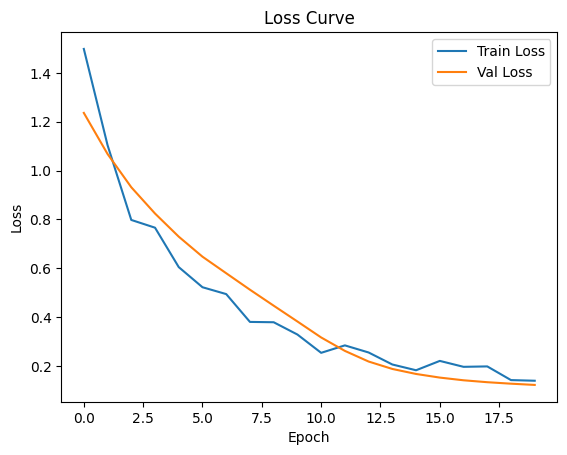

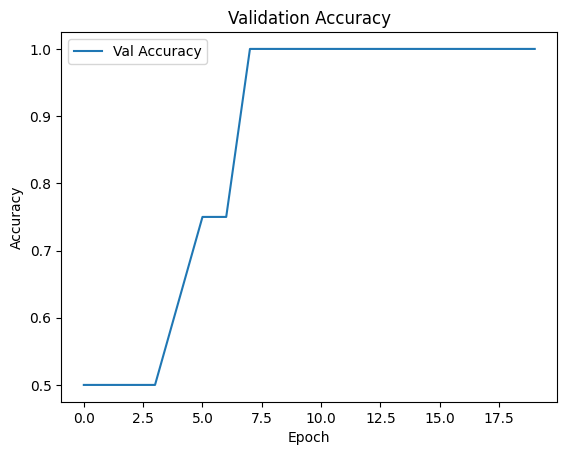

===== Processing Subject 7/7 =====


Training: 100%|██████████| 40/40 [00:01<00:00, 31.14it/s, epoch=20, train_loss=0.1215, val_acc=1.0000]


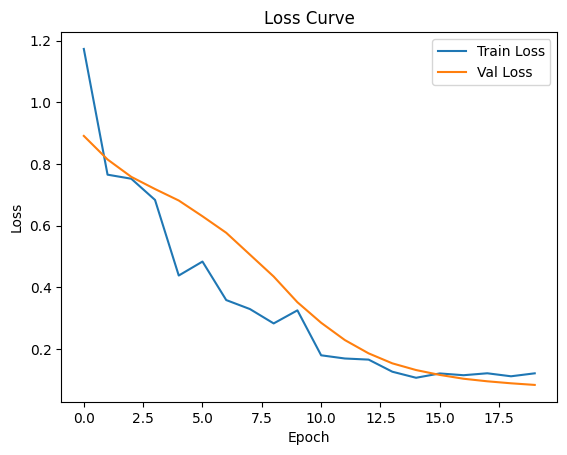

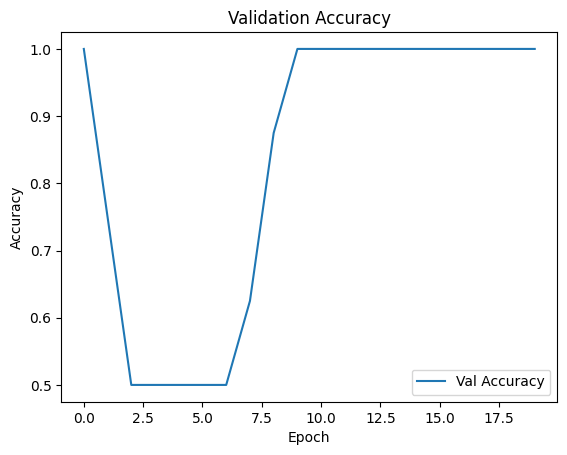

In [29]:
all_results = []
all_preds, all_labels = [], []
for subject_id, raw in enumerate(dataset):
    print(f"===== Processing Subject {subject_id+1}/{len(dataset)} =====")
    X_raw, y_raw = preprocess_raw(raw, event_id=event_id)

    X = np.array(X_raw)
    y = np.array(y_raw)

    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    mean = X_train.mean(axis=(0,2), keepdims=True)
    std  = X_train.std(axis=(0,2), keepdims=True)

    X_train = (X_train - mean) / std
    X_val   = (X_val - mean) / std

    X_train = np.transpose(X_train, (0, 2, 1))  # (N, T, C)
    X_val   = np.transpose(X_val, (0, 2, 1))

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)

    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)

    val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

    model2 = EEGModel(n_channels=X_train.shape[2], n_classes=4)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model2.parameters(), lr=1e-4)

    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #     optimizer,
    #     mode='min',
    #     factor=0.5,
    #     patience=5
    # )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS,     
        eta_min=1e-5 
    )

    history = train(
        model2,
        train_loader,
        val_loader,
        optimizer,
        criterion,        
        scheduler = scheduler,
        epochs=EPOCHS,
        device="cuda" if torch.cuda.is_available() else "cpu"
    )

    plot_history(history)
    val_acc, preds, labels = final_evaluation(model2, val_loader, device)

    all_preds.extend(preds)
    all_labels.extend(labels)

    all_results.append({
        "subject": subject_id,
        "val_accuracy": val_acc
    })


    

Subject 0 → Acc: 1.000
Subject 1 → Acc: 1.000
Subject 2 → Acc: 1.000
Subject 3 → Acc: 1.000
Subject 4 → Acc: 1.000
Subject 5 → Acc: 1.000
Subject 6 → Acc: 1.000


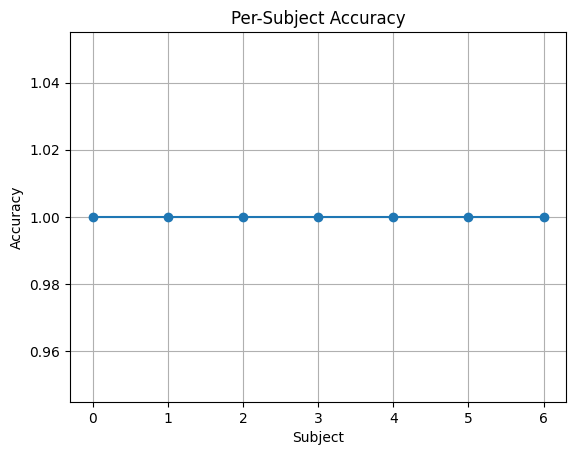

: 

In [ ]:
import pandas as pd
for r in all_results:
    print(f"Subject {r['subject']} → Acc: {r['val_accuracy']:.3f}")

df = pd.DataFrame(all_results)
df.to_csv("bci2a_results.csv", index=False)

import matplotlib.pyplot as plt

accs = [r["val_accuracy"] for r in all_results]

plt.plot(accs, marker='o')
plt.title("Per-Subject Accuracy")
plt.xlabel("Subject")
plt.ylabel("Accuracy")
plt.grid()
plt.show()